executing exhaustive gridsearchcv (this will take several minutes)...
Fitting 3 folds for each of 3456 candidates, totalling 10368 fits


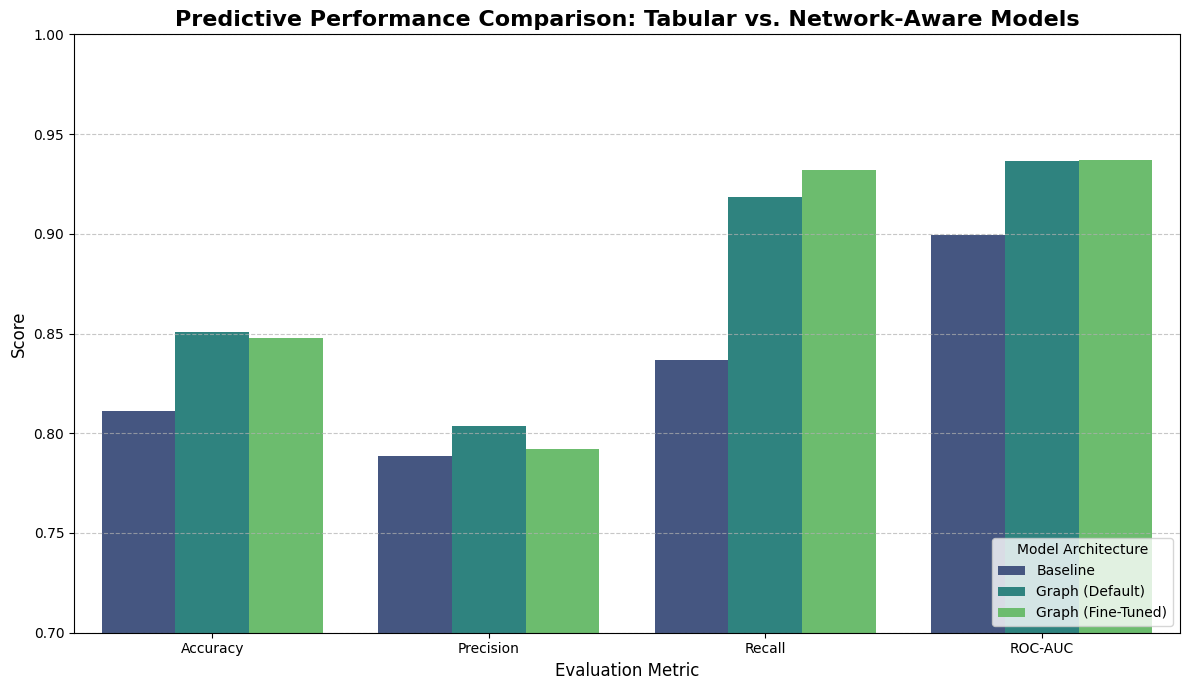


exhaustive search complete. optimal parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

--- newly discovered therapeutic candidates ---
found 0 highly probable hidden links.
Empty DataFrame
Columns: [source, target, predicted_probability]
Index: []


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

ml_dataset = pd.read_csv('baseline_ml_dataset.csv')
graph_metrics = pd.read_csv('graph_metrics.csv')

ml_dataset = ml_dataset.merge(graph_metrics, left_on='source', right_on='id', how='left').rename(columns={
    'pagerank': 'compound_pagerank', 'betweenness': 'compound_betweenness',
    'eigenvector': 'compound_eigenvector', 'louvain': 'compound_louvain',
    'lpa': 'compound_lpa', 'clustering': 'compound_clustering'
}).drop(columns=['id'])

ml_dataset = ml_dataset.merge(graph_metrics, left_on='target', right_on='id', how='left').rename(columns={
    'pagerank': 'disease_pagerank', 'betweenness': 'disease_betweenness',
    'eigenvector': 'disease_eigenvector', 'louvain': 'disease_louvain',
    'lpa': 'disease_lpa', 'clustering': 'disease_clustering'
}).drop(columns=['id'])

ml_dataset['same_louvain_community'] = (ml_dataset['compound_louvain'] == ml_dataset['disease_louvain']).astype(int)
ml_dataset.fillna(0, inplace=True)

y = ml_dataset['label']

baseline_features = ['compound_out_degree', 'compound_in_degree', 'disease_out_degree', 'disease_in_degree']
X_baseline = ml_dataset[baseline_features]

graph_features = baseline_features + [
    'compound_pagerank', 'disease_pagerank', 'compound_betweenness', 'disease_betweenness',
    'compound_eigenvector', 'disease_eigenvector', 'compound_clustering', 'disease_clustering',
    'same_louvain_community'
]
X_graph = ml_dataset[graph_features]

# retaining the original indices to map predictions back to specific compound and disease IDs later
X_base_train, X_base_test, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)
X_graph_train, X_graph_test, _, _ = train_test_split(X_graph, y, test_size=0.2, random_state=42)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_base_train, y_train)
base_preds = rf_baseline.predict(X_base_test)
base_probs = rf_baseline.predict_proba(X_base_test)[:, 1]

rf_graph = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_graph.fit(X_graph_train, y_train)
graph_preds = rf_graph.predict(X_graph_test)
graph_probs = rf_graph.predict_proba(X_graph_test)[:, 1]

param_grid = {
    'n_estimators': [100, 200, 500, 1000],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
}

print("executing exhaustive gridsearchcv (this will take several minutes)...")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

grid_search.fit(X_graph_train, y_train)
best_rf_model = grid_search.best_estimator_

tuned_preds = best_rf_model.predict(X_graph_test)
tuned_probs = best_rf_model.predict_proba(X_graph_test)[:, 1]

# compiling all metrics for the visual presentation
metrics_data = {
    'Model': ['Baseline', 'Baseline', 'Baseline', 'Baseline',
              'Graph (Default)', 'Graph (Default)', 'Graph (Default)', 'Graph (Default)',
              'Graph (Fine-Tuned)', 'Graph (Fine-Tuned)', 'Graph (Fine-Tuned)', 'Graph (Fine-Tuned)'],
    'Metric': ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'] * 3,
    'Score': [
        accuracy_score(y_test, base_preds), precision_score(y_test, base_preds), recall_score(y_test, base_preds), roc_auc_score(y_test, base_probs),
        accuracy_score(y_test, graph_preds), precision_score(y_test, graph_preds), recall_score(y_test, graph_preds), roc_auc_score(y_test, graph_probs),
        accuracy_score(y_test, tuned_preds), precision_score(y_test, tuned_preds), recall_score(y_test, tuned_preds), roc_auc_score(y_test, tuned_probs)
    ]
}

metrics_df = pd.DataFrame(metrics_data)

# generating the grouped bar chart for model comparison
plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Predictive Performance Comparison: Tabular vs. Network-Aware Models', fontsize=16, fontweight='bold')
plt.ylim(0.7, 1.0)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.legend(title='Model Architecture', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300)
plt.show()

# isolating novel discoveries: pairs with a ground truth of 0, but a high probability prediction of 1
test_indices = X_graph_test.index
results_df = ml_dataset.loc[test_indices, ['source', 'target', 'label']].copy()
results_df['predicted_probability'] = tuned_probs
results_df['prediction'] = tuned_preds

# filtering for newly discovered therapeutic links with a confidence threshold above 85%
discoveries = results_df[(results_df['label'] == 0) & (results_df['predicted_probability'] >= 0.85)].copy()
discoveries.sort_values(by='predicted_probability', ascending=False, inplace=True)

print(f"\nexhaustive search complete. optimal parameters: {grid_search.best_params_}")
print(f"\n--- newly discovered therapeutic candidates ---")
print(f"found {len(discoveries)} highly probable hidden links.")
print(discoveries[['source', 'target', 'predicted_probability']].head(20))

In [ ]:
print(best_rf_model.get_params())
print(metrics_df)

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
                 Model     Metric     Score
0             Baseline   Accuracy  0.811258
1             Baseline  Precision  0.788462
2             Baseline     Recall  0.836735
3             Baseline    ROC-AUC  0.899342
4      Graph (Default)   Accuracy  0.850993
5      Graph (Default)  Precision  0.803571
6      Graph (Default)     Recall  0.918367
7      Graph (Default)    ROC-AUC  0.936625
8   Graph (Fine-Tuned)   Accuracy  0.847682
9   Graph (Fine-Tuned)  Precision  0.791908
10  Graph (Fine-Tuned)     Recall  0.931973
11  Graph (Fine-Tuned)    ROC-AUC  0.936888


/tmp/ipykernel_23338/3244331171.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance_score', y='feature', palette='mako')


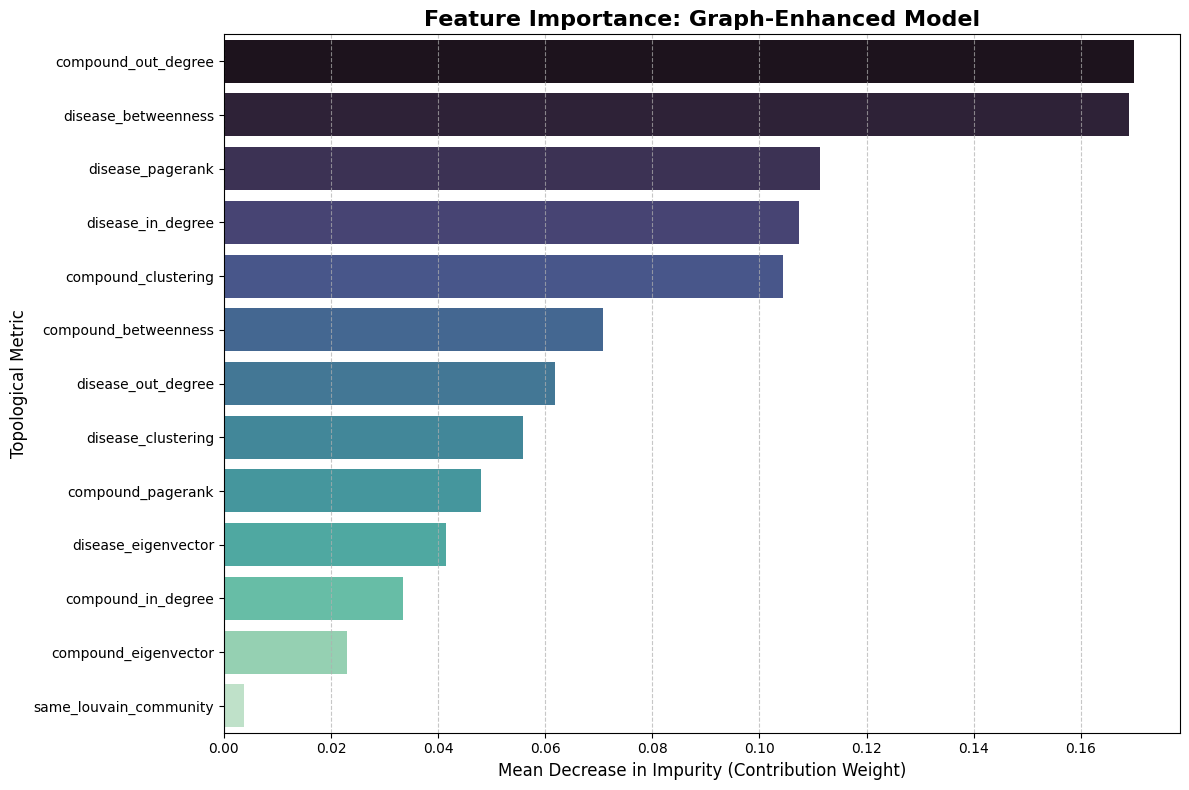


--- absolute feature contribution rankings ---
               feature  importance_score
   compound_out_degree          0.170030
   disease_betweenness          0.168987
      disease_pagerank          0.111258
     disease_in_degree          0.107446
   compound_clustering          0.104442
  compound_betweenness          0.070744
    disease_out_degree          0.061847
    disease_clustering          0.055758
     compound_pagerank          0.047946
   disease_eigenvector          0.041506
    compound_in_degree          0.033363
  compound_eigenvector          0.023010
same_louvain_community          0.003664


In [ ]:
# extracting the calculated feature importances from the optimized random forest model
importances = best_rf_model.feature_importances_
feature_names = X_graph.columns

# compiling the metrics into a structured dataframe for sorting and visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_score': importances
}).sort_values(by='importance_score', ascending=False)

# generating a high-resolution horizontal bar chart for the presentation
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='importance_score', y='feature', palette='mako')
plt.title('Feature Importance: Graph-Enhanced Model', fontsize=16, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (Contribution Weight)', fontsize=12)
plt.ylabel('Topological Metric', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# saving the visual artifact for the final slide deck
plt.savefig('feature_importance_chart.png', dpi=300)
plt.show()

print("\n--- absolute feature contribution rankings ---")
print(importance_df.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import itertools

print("initializing exhaustive search space from scratch...")

# 1. extract all unique compounds and diseases from your baseline dataset
compounds = ml_dataset['source'].unique()
diseases = ml_dataset['target'].unique()

# 2. generate the cartesian product (every possible combination of drug and disease)
all_possible_pairs = pd.DataFrame(list(itertools.product(compounds, diseases)), columns=['source', 'target'])

# 3. isolate known ground-truth links to filter them out of the discovery pool
known_links = ml_dataset[ml_dataset['label'] == 1][['source', 'target']].drop_duplicates()

# 4. subtract the known links from the total pool using an anti-join
unseen_pairs = all_possible_pairs.merge(known_links, on=['source', 'target'], how='left', indicator=True)
unseen_pairs = unseen_pairs[unseen_pairs['_merge'] == 'left_only'].drop(columns=['_merge'])

print("merging baseline and topological graph features...")

# 5a. extract the static baseline degree counts from the original training data
compound_degrees = ml_dataset[['source', 'compound_out_degree', 'compound_in_degree']].drop_duplicates()
disease_degrees = ml_dataset[['target', 'disease_out_degree', 'disease_in_degree']].drop_duplicates()

# 5b. merge the baseline degree features into the unseen universe
unseen_pairs = unseen_pairs.merge(compound_degrees, on='source', how='left')
unseen_pairs = unseen_pairs.merge(disease_degrees, on='target', how='left')

# 5c. dynamically map the structural neo4j metrics to the massive unseen dataframe
unseen_pairs = unseen_pairs.merge(graph_metrics, left_on='source', right_on='id', how='left').rename(columns={
    'pagerank': 'compound_pagerank', 'betweenness': 'compound_betweenness',
    'eigenvector': 'compound_eigenvector', 'louvain': 'compound_louvain',
    'lpa': 'compound_lpa', 'clustering': 'compound_clustering'
}).drop(columns=['id'])

unseen_pairs = unseen_pairs.merge(graph_metrics, left_on='target', right_on='id', how='left').rename(columns={
    'pagerank': 'disease_pagerank', 'betweenness': 'disease_betweenness',
    'eigenvector': 'disease_eigenvector', 'louvain': 'disease_louvain',
    'lpa': 'disease_lpa', 'clustering': 'disease_clustering'
}).drop(columns=['id'])

# 6. engineer the critical community heuristic
unseen_pairs['same_louvain_community'] = (unseen_pairs['compound_louvain'] == unseen_pairs['disease_louvain']).astype(int)
unseen_pairs.fillna(0, inplace=True)

# explicitly order the columns to perfectly match the training matrix
X_exhaustive = unseen_pairs[graph_features]

print("executing batch inference through the fine-tuned model...")

# 7. predict probabilities in safely defined batches to protect local ram limits
batch_size = 50000
probabilities = np.zeros(len(X_exhaustive))

for i in range(0, len(X_exhaustive), batch_size):
    batch = X_exhaustive.iloc[i:i+batch_size]
    probabilities[i:i+batch_size] = best_rf_model.predict_proba(batch)[:, 1]
    print(f"processed {(i+len(batch)):,}/{len(X_exhaustive):,} pairs...")

unseen_pairs['predicted_probability'] = probabilities

print("\n--- extracting definitive novel discoveries ---")

# 8. sort the entire universe of possibilities to find the absolute highest probability links
final_discoveries = unseen_pairs[['source', 'target', 'predicted_probability']].sort_values(by='predicted_probability', ascending=False)

# filtering for the strict > 85% confidence threshold established for the analysis
top_tier_candidates = final_discoveries[final_discoveries['predicted_probability'] >= 0.85]

print(f"system sweep complete. found {len(top_tier_candidates)} highly probable novel therapeutic candidates.")
print(top_tier_candidates.head(20))

initializing exhaustive search space from scratch...
merging baseline and topological graph features...
executing batch inference through the fine-tuned model...
processed 50,000/112,681 pairs...
processed 100,000/112,681 pairs...
processed 112,681/112,681 pairs...

--- extracting definitive novel discoveries ---
system sweep complete. found 3578 highly probable novel therapeutic candidates.
                   source               target  predicted_probability
11610   Compound::DB01177  Disease::DOID:10763               0.986728
27957   Compound::DB00359  Disease::DOID:10763               0.986164
42213   Compound::DB00945  Disease::DOID:10763               0.984539
1190    Compound::DB00635  Disease::DOID:10763               0.984450
11631   Compound::DB01177   Disease::DOID:2841               0.983940
5447    Compound::DB00570   Disease::DOID:2841               0.982506
16716   Compound::DB01077  Disease::DOID:10763               0.982419
69664   Compound::DB00717  Disease::DOID:1076

In [ ]:
# executing final translation of database ids to biological names

import pandas as pd

print("loading biological node dictionary...")

# loading the standard hetionet nodes file containing the text names for all entities
# ensure 'nodes.tsv' is uploaded to your current colab session
nodes_df = pd.read_csv('nodes.tsv', sep='\t')

# creating a lightning-fast lookup dictionary mapping the raw id to the human-readable name
id_to_name_mapping = dict(zip(nodes_df['id'], nodes_df['name']))

print("translating discovery matrix...")

# applying the mapping dictionary directly to our top tier discoveries dataframe
top_tier_candidates['compound_name'] = top_tier_candidates['source'].map(id_to_name_mapping)
top_tier_candidates['disease_name'] = top_tier_candidates['target'].map(id_to_name_mapping)

# restructuring the final dataframe for maximum readability during the presentation
presentation_df = top_tier_candidates[
    ['compound_name', 'disease_name', 'predicted_probability']
].copy()

# formatting the raw probability float into a clean, readable percentage
presentation_df['ai_confidence'] = (presentation_df['predicted_probability'] * 100).round(2).astype(str) + '%'

print("\n--- final presentation-ready therapeutic discoveries ---")
print(presentation_df[['compound_name', 'disease_name', 'ai_confidence']].head(20).to_string(index=False))

loading biological node dictionary...
translating discovery matrix...

--- final presentation-ready therapeutic discoveries ---
       compound_name            disease_name ai_confidence
          Idarubicin            hypertension        98.67%
        Sulfadiazine            hypertension        98.62%
Acetylsalicylic acid            hypertension        98.45%
          Prednisone            hypertension        98.44%
          Idarubicin                  asthma        98.39%
         Vinblastine                  asthma        98.25%
      Etidronic acid            hypertension        98.24%
       Norethindrone            hypertension        98.19%
           Flutamide            hypertension        98.08%
          Salbutamol            hypertension        98.06%
          Nizatidine            hypertension        98.01%
       Pyrimethamine            hypertension        97.94%
       Betamethasone            hypertension        97.89%
         Fulvestrant                  asthma  

/tmp/ipykernel_23338/185942423.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_tier_candidates['compound_name'] = top_tier_candidates['source'].map(id_to_name_mapping)
/tmp/ipykernel_23338/185942423.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_tier_candidates['disease_name'] = top_tier_candidates['target'].map(id_to_name_mapping)


generating high-resolution discovery subgraph...


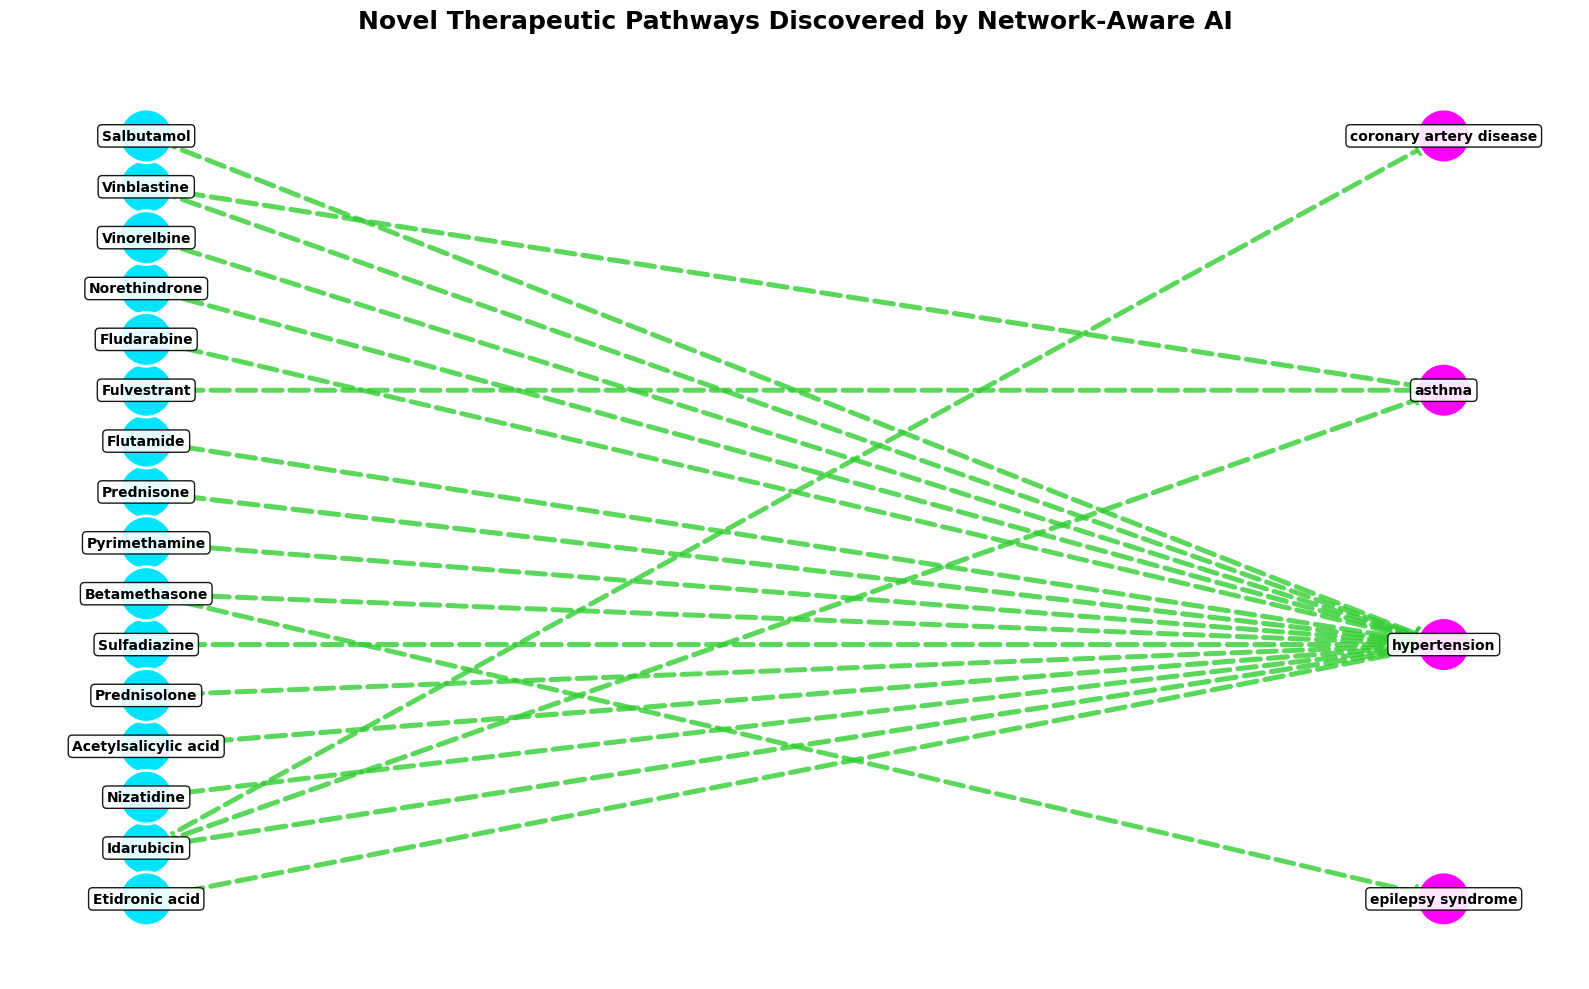

network visualization saved as 'novel_discoveries_network.png'


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

print("generating high-resolution discovery subgraph...")

# selecting the top 20 most confident discoveries to avoid overcrowding the visual
plot_df = presentation_df.head(20).copy()

# initializing a directional graph
G_discoveries = nx.DiGraph()

# iterating through the dataframe to build nodes and weighted edges
for _, row in plot_df.iterrows():
    compound = row['compound_name']
    disease = row['disease_name']

    # converting the percentage string (e.g., "92.45%") back to a float for math mapping
    confidence_score = float(row['ai_confidence'].replace('%', ''))

    # adding nodes with a type attribute for color coding
    G_discoveries.add_node(compound, node_type='Compound')
    G_discoveries.add_node(disease, node_type='Disease')

    # adding the predicted edge, using the confidence score as the weight
    G_discoveries.add_edge(compound, disease, weight=confidence_score)

# setting up the visual parameters
plt.figure(figsize=(16, 10))
plt.title("Novel Therapeutic Pathways Discovered by Network-Aware AI", fontsize=18, fontweight='bold', pad=20)

# calculating a bipartite layout to clearly separate drugs from diseases
# placing compounds on the left (x=1) and diseases on the right (x=2)
pos = nx.bipartite_layout(G_discoveries, nodes=[n for n, d in G_discoveries.nodes(data=True) if d['node_type'] == 'Compound'])

# defining node colors based on entity type
node_colors = []
for node in G_discoveries.nodes():
    if G_discoveries.nodes[node]['node_type'] == 'Compound':
        node_colors.append('#00E5FF') # cyan for compounds
    else:
        node_colors.append('#FF00FF') # magenta for diseases

# scaling the edge thickness based on the AI confidence score
# subtracting 80 to make the differences in the 85-99% range visually distinct
edges = G_discoveries.edges()
weights = [G_discoveries[u][v]['weight'] for u, v in edges]
normalized_weights = [(w - 80) / 5 for w in weights]

# drawing the graph components
nx.draw_networkx_nodes(G_discoveries, pos, node_size=1500, node_color=node_colors, edgecolors='white', linewidths=2)

nx.draw_networkx_edges(
    G_discoveries, pos,
    edgelist=edges,
    width=normalized_weights,
    edge_color='#32CD32', # lime green
    style='dashed',
    alpha=0.8,
    arrowsize=20
)

# adding readable labels with a bounding box for clarity
nx.draw_networkx_labels(
    G_discoveries, pos,
    font_size=10,
    font_weight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.9)
)

# final cleanup and export
plt.axis('off')
plt.tight_layout()
plt.savefig('novel_discoveries_network.png', dpi=300, bbox_inches='tight', facecolor='#F5F5F5')
plt.show()

print("network visualization saved as 'novel_discoveries_network.png'")

In [ ]:
# profiling the topological architecture of the novel discoveries vs rejected pairs

import pandas as pd

print("calculating topological profiles for discoveries vs. rejected pairs...")

# building a clean dataframe directly from the raw feature matrix and probability array
# this mathematically guarantees no missing columns or memory state collisions
profile_df = X_exhaustive.copy()
profile_df['predicted_probability'] = probabilities

# isolating the high-confidence discoveries
discoveries_profile = profile_df[profile_df['predicted_probability'] >= 0.85].copy()

# isolating a random sample of the rejected background noise for comparison
# matching the exact sample size of the discoveries for a mathematically fair comparison
rejected_profile = profile_df[profile_df['predicted_probability'] < 0.10].sample(n=len(discoveries_profile), random_state=42)

# calculating the percentage of pairs that share a louvain community
disc_community_match = (discoveries_profile['same_louvain_community'].mean() * 100)
rej_community_match = (rejected_profile['same_louvain_community'].mean() * 100)

# aggregating the mean values for the critical neo4j centrality metrics
profile_comparison = pd.DataFrame({
    'Metric': [
        'Shared Louvain Community (%)',
        'Avg Compound Betweenness',
        'Avg Disease PageRank',
        'Avg Compound Clustering',
        'Avg Disease Eigenvector'
    ],
    'Novel Discoveries (>85% Conf)': [
        f"{disc_community_match:.1f}%",
        f"{discoveries_profile['compound_betweenness'].mean():.4f}",
        f"{discoveries_profile['disease_pagerank'].mean():.4f}",
        f"{discoveries_profile['compound_clustering'].mean():.4f}",
        f"{discoveries_profile['disease_eigenvector'].mean():.4f}"
    ],
    'Rejected Pairs (<10% Conf)': [
        f"{rej_community_match:.1f}%",
        f"{rejected_profile['compound_betweenness'].mean():.4f}",
        f"{rejected_profile['disease_pagerank'].mean():.4f}",
        f"{rejected_profile['compound_clustering'].mean():.4f}",
        f"{rejected_profile['disease_eigenvector'].mean():.4f}"
    ]
})

print("\n--- topological profile comparison ---")
print(profile_comparison.to_string(index=False))

calculating topological profiles for discoveries vs. rejected pairs...

--- topological profile comparison ---
                      Metric Novel Discoveries (>85% Conf) Rejected Pairs (<10% Conf)
Shared Louvain Community (%)                          8.6%                      13.2%
    Avg Compound Betweenness                    27891.5688                 13773.7188
        Avg Disease PageRank                        0.2198                     0.1580
     Avg Compound Clustering                        0.0266                     0.1914
     Avg Disease Eigenvector                        0.0000                     0.0000
